In [22]:
import rasterio
from rasterio.warp import reproject, calculate_default_transform, Resampling
import logging
import os
import numpy as np
import pandas as pd
import re
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
classified_dir = '../../../data/processed/classified'

In [3]:
#aligned rasters
lulc_2010 = os.path.join(classified_dir, 'lulc_2010.tif')
lulc_2015 = os.path.join(classified_dir, 'lulc_2015.tif')
lulc_2020 = os.path.join(classified_dir, 'lulc_2020.tif')
lulc_2025 = os.path.join(classified_dir, 'lulc_2025.tif')

In [4]:
def coregister_raster(src_path: str, dest_path: str, ref_path: str) -> None:
        """Reproject and align raster to match reference raster."""
        #open the raster to be aligned
        with rasterio.open(src_path) as src:
            src_transform = src.transform
            #open the reference raster/ raster with target dimensions and resolution
            with rasterio.open(ref_path) as ref:
                dst_crs = ref.crs
                dst_transform, dst_width, dst_height = calculate_default_transform(
                    src.crs,    
                    dst_crs,    
                    ref.width,   
                    ref.height,  
                    *ref.bounds,
                )
                dst_kwargs = src.meta.copy()
                dst_kwargs.update({
                                "crs": dst_crs,
                                "transform": dst_transform,
                                "width": dst_width,
                                "height": dst_height,
                                "nodata": 0,
                                "dtype": src.meta["dtype"],})
                #write the aligned raster
                with rasterio.open(dest_path, 'w', **dst_kwargs) as dst:
                    for i in range(1, src.count + 1):
                        reproject(
                            source=rasterio.band(src, i),
                            destination=rasterio.band(dst, i),
                            src_transform=src.transform,
                            src_crs=src.crs,
                            dst_transform=dst_transform,
                            dst_crs=dst_crs,
                            resampling=Resampling.nearest#nearest resampling avoids overstretching rasters, esp given we are moving from 10m to around 3m
                        )

        print(f"Coregistered: {os.path.basename(src_path)} to {dest_path}")
            

In [5]:
def mask(src_file, plots_path, output_path):
    with rasterio.open(src_file) as src:
        crs = src.crs
        gdf = gpd.read_file(plots_path).to_crs('EPSG:4326')
        geoms = [feature["geometry"] for feature in gdf.__geo_interface__["features"]]
        out_image, out_transform = rasterio.mask.mask(src, geoms, crop=True)
        out_meta = src.meta
        out_meta.update({"driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform})
    with rasterio.open(output_path, 'w', **out_meta) as dest:
        dest.write(out_image)
    logging.info('Clipping complete.')

In [6]:
coregister_raster(lulc_2015, os.path.join(classified_dir, 'lulc_2015_aligned.tif'), lulc_2010)
coregister_raster(lulc_2020, os.path.join(classified_dir, 'lulc_2020_aligned.tif'), lulc_2010)
coregister_raster(lulc_2025, os.path.join(classified_dir, 'lulc_2025_aligned.tif'), lulc_2010)

Coregistered: lulc_2015.tif to ../../../data/processed/classified\lulc_2015_aligned.tif
Coregistered: lulc_2020.tif to ../../../data/processed/classified\lulc_2020_aligned.tif
Coregistered: lulc_2025.tif to ../../../data/processed/classified\lulc_2025_aligned.tif


In [100]:
lulc_2015 = os.path.join(classified_dir, 'lulc_2015_aligned.tif')
lulc_2020 = os.path.join(classified_dir, 'lulc_2020_aligned.tif')
lulc_2025 = os.path.join(classified_dir, 'lulc_2025_aligned.tif')
indices_path = '../../../data/processed/quarterly.csv'

In [56]:
def compute_landcover_area_single_raster(
    raster_path,
    class_map={1: "forest", 2: "sparse_woody", 3: "open", 4: "water"}
):
    """
    Computes area (km²) per landcover class for a single categorical raster.

    Parameters
    ----------
    raster_path : str or Path
        Path to categorical landcover raster.
    class_map : dict
        Mapping of class_id -> class_name.

    Returns
    -------
    pandas.DataFrame
        Columns: year, class_id, class_name, area_km2
    """

    raster_path = Path(raster_path)

    # ---- infer year from filename ----
    match = re.search(r"(19|20)\d{2}", raster_path.name)
    if not match:
        raise ValueError(f"Year not found in filename: {raster_path.name}")

    year = int(match.group())

    with rasterio.open(raster_path) as src:
        if not src.crs or not src.crs.is_projected:
            raise ValueError("Raster must be in a projected CRS for area calculation.")

        data = src.read(1)
        transform = src.transform
        nodata = src.nodata

        # ---- pixel area (m²) ----
        pixel_area_m2 = abs(transform.a * transform.e)

        # ---- mask NoData ----
        if nodata is not None:
            data = data[data != nodata]

        records = []

        for class_id, class_name in class_map.items():
            pixel_count = np.sum(data == class_id)
            area_km2 = (pixel_count * pixel_area_m2) / 1_000_000

            records.append({
                "year": year,
                "class_id": class_id,
                "class_name": class_name,
                "area_km2": area_km2
            })

    return pd.DataFrame(records)


In [57]:
area_2010 = compute_landcover_area_single_raster(lulc_2010)
area_2015 = compute_landcover_area_single_raster(lulc_2015)
area_2020 = compute_landcover_area_single_raster(lulc_2020)
area_2025 = compute_landcover_area_single_raster(lulc_2025)

In [58]:
area_2010

,year,class_id,class_name,area_km2
0,2010,1,forest,11.946581
1,2010,2,sparse_woody,39.870841
2,2010,3,open,13.043369
3,2010,4,water,1.709594


In [59]:
area_2015

,year,class_id,class_name,area_km2
0,2015,1,forest,15.831859
1,2015,2,sparse_woody,31.587676
2,2015,3,open,17.796415
3,2015,4,water,1.354435


In [60]:
area_2020

,year,class_id,class_name,area_km2
0,2020,1,forest,10.095639
1,2020,2,sparse_woody,25.666273
2,2020,3,open,29.223230
3,2020,4,water,1.585243


In [61]:
area_2025

,year,class_id,class_name,area_km2
0,2025,1,forest,20.791559
1,2025,2,sparse_woody,27.829432
2,2025,3,open,16.489395
3,2025,4,water,1.459998


In [62]:
areas_df = pd.concat([area_2010, area_2015, area_2020, area_2025], ignore_index=True)
areas_df = areas_df.sort_values('year')

In [63]:
areas_df

,year,class_id,class_name,area_km2
0,2010,1,forest,11.946581
1,2010,2,sparse_woody,39.870841
2,2010,3,open,13.043369
3,2010,4,water,1.709594
4,2015,1,forest,15.831859
5,2015,2,sparse_woody,31.587676
6,2015,3,open,17.796415
7,2015,4,water,1.354435
8,2020,1,forest,10.095639
9,2020,2,sparse_woody,25.666273


In [101]:
indices_df = pd.read_csv(indices_path)

In [102]:
indices_df.head()

,system:index,MSAVI,NDVI,end_date,quarter,start_date,total_rainfall_mm,year,.geo
0,0,0.101680,0.056642,2010-04-01,1,2010-01-01,673.832021,2010.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1,0.232545,0.131931,2010-07-01,2,2010-04-01,333.888974,2010.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2,0.176625,0.096867,2010-10-01,3,2010-07-01,1.604513,2010.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3,0.259829,0.157210,2011-01-01,4,2010-10-01,780.920853,2010.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,4,0.310553,0.186506,2011-04-01,1,2011-01-01,549.917556,2011.0,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [103]:
indices_df['year'] = indices_df['year'].astype('int')

In [104]:
target_years = [2010, 2015, 2020, 2025]

df_subset = indices_df[indices_df["year"].isin(target_years)].copy()

In [105]:
df_subset.isna().sum()


system:index         0
MSAVI                0
NDVI                 0
end_date             0
quarter              0
start_date           0
total_rainfall_mm    0
year                 0
.geo                 0
dtype: int64

In [106]:
agg_df = (
    df_subset
    .groupby("year")
    .agg(
        total_rainfall_mm=("total_rainfall_mm", "sum"),
        mean_ndvi=("NDVI", "mean"),
        mean_msavi=("MSAVI", "mean"),
        n_quarters=("year", "count")
    )
    .reset_index()
)

agg_df


,year,total_rainfall_mm,mean_ndvi,mean_msavi,n_quarters
0,2010,1790.246360,0.110662,0.192670,4
1,2015,2425.667748,0.159171,0.260128,4
2,2020,2408.514725,0.368177,0.500040,4
3,2025,2193.999462,0.185778,0.300788,4


In [107]:
type(areas_df)

pandas.DataFrame

In [120]:
import seaborn as sns


def plot_landcover_change_vs_baseline(
    df,
    class_name,
    baseline_year=2010
):
    """
    Plots landcover area change for a single class against a no-change baseline.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing year, class_name, area_km2
    class_name : str
        Landcover class to plot (e.g. 'forest')
    baseline_year : int
        Year used as counterfactual baseline
    """

    sns.set_theme(
        style="whitegrid",
        context="notebook"
    )

    class_df = (
        df[df["class_name"] == class_name]
        .sort_values("year")
        .copy()
    )

    if baseline_year not in class_df["year"].values:
        raise ValueError(f"{baseline_year} not found for {class_name}")

    baseline_area = class_df.loc[
        class_df["year"] == baseline_year, "area_km2"
    ].values[0]

    plt.figure(figsize=(9, 5))

    # Observed trend
    sns.lineplot(
        data=class_df,
        x="year",
        y="area_km2",
        marker="o",
        linewidth=3,
        label="Observed land-cover area"
    )

    # Baseline (no-change counterfactual)
    plt.axhline(
        y=baseline_area,
        linestyle="--",
        linewidth=2,
        color='red',
        label=f"{baseline_year} baseline (no change)"
    )

    plt.title(
        f"{class_name.replace('_', ' ').title()} Area Change Relative to Baseline",
        pad=15
    )
    plt.xlabel("Year")
    plt.ylabel("Area (km²)")
    plt.legend(frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f'{classified_dir}/{class_name}_change.png', dpi = 400)
    plt.show()


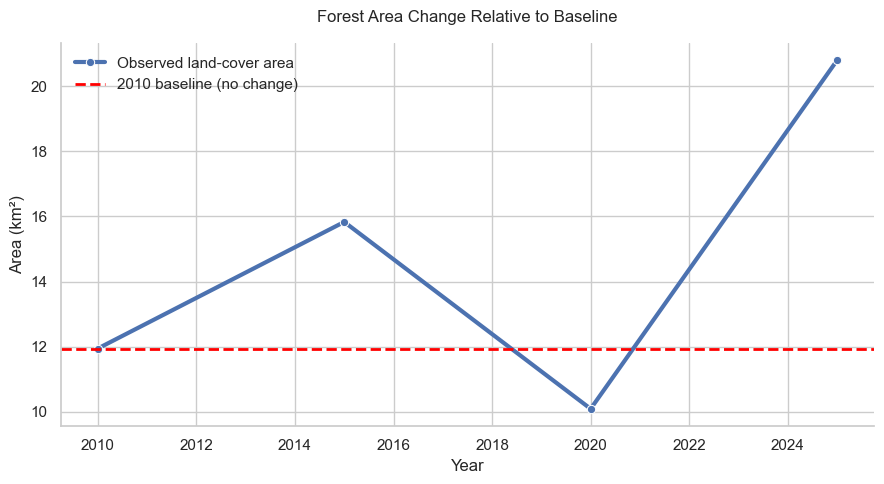

In [121]:
plot_landcover_change_vs_baseline(
    areas_df,
    class_name="forest"
)

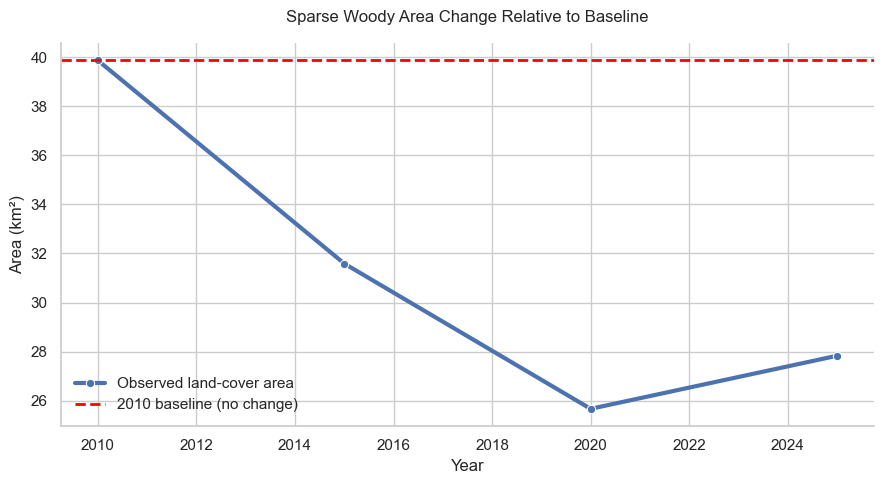

In [122]:
plot_landcover_change_vs_baseline(
    areas_df,
    class_name="sparse_woody"
)

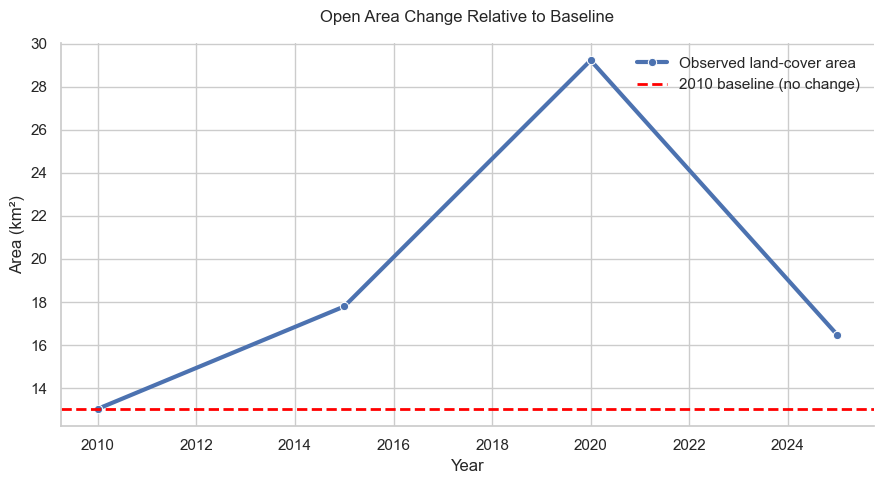

In [123]:
plot_landcover_change_vs_baseline(
    areas_df,
    class_name="open"
)

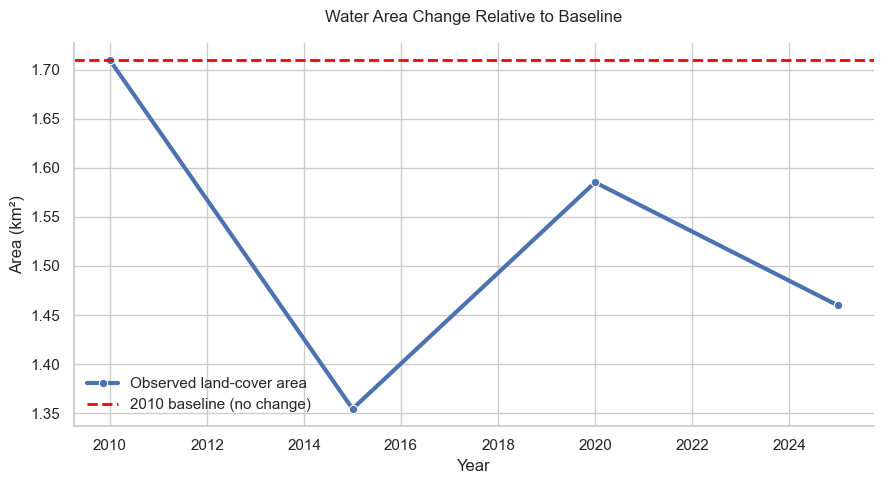

In [124]:
plot_landcover_change_vs_baseline(
    areas_df,
    class_name="water"
)

In [108]:
agg_df = (
    indices_df
    .groupby("year")
    .agg(
        total_rainfall_mm=("total_rainfall_mm", "sum"),
        mean_ndvi=("NDVI", "mean"),
        mean_msavi=("MSAVI", "mean"),
        n_quarters=("year", "count")
    )
    .reset_index()
)

agg_df


,year,total_rainfall_mm,mean_ndvi,mean_msavi,n_quarters
0,2010,1790.246360,0.110662,0.192670,4
1,2011,1746.795520,0.113897,0.198472,4
2,2012,1701.232715,NaN,NaN,4
3,2013,1649.924544,0.136641,0.226384,4
4,2014,1399.486615,0.162117,0.264163,4
5,2015,2425.667748,0.159171,0.260128,4
6,2016,1763.800486,0.139832,0.232049,4
7,2017,1312.297808,0.136710,0.230469,4
8,2018,2774.590478,0.337873,0.472616,4
9,2019,2553.893574,0.262699,0.377913,4


In [109]:
agg_df = agg_df.dropna()

In [127]:
def plot_ndvi_msavi_with_rainfall(df):
    """
    Clean dual-axis plot showing NDVI & MSAVI overlaid on rainfall.
    No smoothing, no regression.
    """

    sns.set_theme(style="whitegrid", context="notebook")
    df = df.sort_values("year")

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # ---- Vegetation indices (LEFT axis) ----
    sns.lineplot(
        data=df,
        x="year",
        y="mean_ndvi",
        marker="o",
        linewidth=2.8,
        ax=ax1,
        label="NDVI"
    )

    sns.lineplot(
        data=df,
        x="year",
        y="mean_msavi",
        marker="s",
        linewidth=2.8,
        ax=ax1,
        label="MSAVI"
    )

    ax1.set_ylabel("Vegetation Index Value")
    ax1.set_xlabel("Year")
    ax1.set_ylim(0, 0.6)  # IMPORTANT: keep indices visible

    # ---- Rainfall (RIGHT axis, background) ----
    ax2 = ax1.twinx()
    ax2.bar(
        df["year"],
        df["total_rainfall_mm"],
        alpha=0.25,
        width=0.6,
        zorder=0
    )

    ax2.set_ylabel("Total Rainfall (mm)")

    # ---- Title & legend ----
    ax1.set_title(
        "NDVI and MSAVI in Relation to Annual Rainfall",
        pad=15
    )

    ax1.legend(frameon=False, loc="upper left")

    sns.despine(right=False)
    plt.tight_layout()
    plt.savefig(f'{classified_dir}/total_rainfall.png', dpi = 400)
    plt.show()

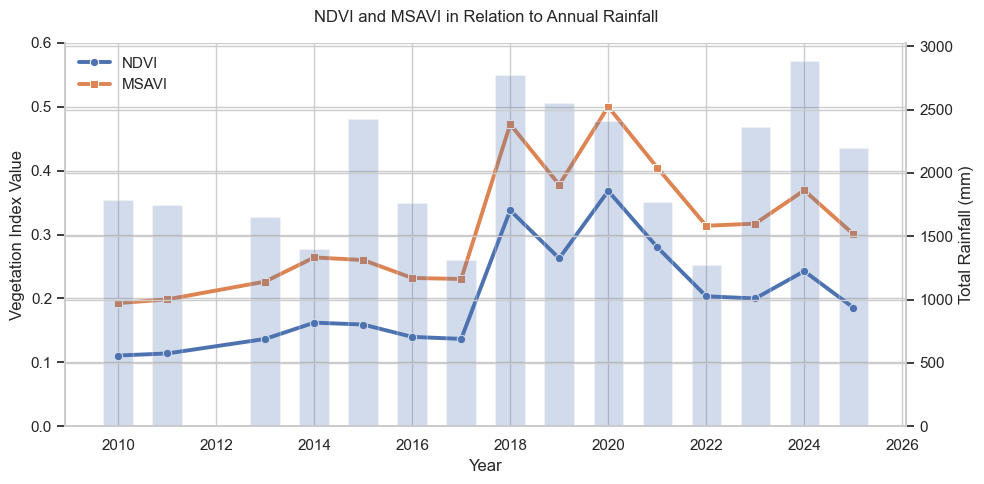

In [128]:
plot_ndvi_msavi_with_rainfall(agg_df)